n	среднее(мс)		tразброс(мс)
----------------------------------------
10	0.010	0.004
50	0.053	0.009
100	0.124	0.044
200	0.282	0.054
300	0.415	0.036
400	0.609	0.035
500	1.152	0.333


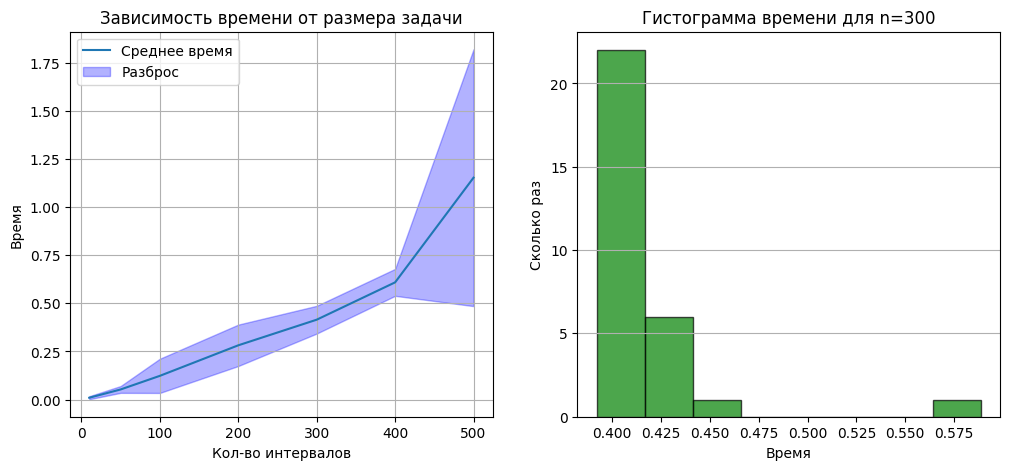

In [18]:
import random
import time
import math
import matplotlib.pyplot as plt

class Interval:
    def __init__(self, start, finish, weight):
        self.start = start
        self.finish = finish
        self.weight = weight

def binary_search(intervals, i):
    left = 0
    right = i - 1
    result = -1
    while left <= right:
        mid = (left + right) // 2
        if intervals[mid].finish <= intervals[i].start:
            result = mid
            left = mid + 1
        else:
            right = mid - 1
    return result

def solve(intervals):
    intervals.sort(key=lambda x: x.finish)
    n = len(intervals)

    p = [-1] * n
    for i in range(n):
        p[i] = binary_search(intervals, i)

    dp = [0] * n
    for i in range(n):
        take = intervals[i].weight
        if p[i] != -1:
            take += dp[p[i]]
        not_take = dp[i-1] if i > 0 else 0
        dp[i] = max(take, not_take)

    return dp[n-1]

def gen(n):
    intervals = []
    for _ in range(n):
        start = random.randint(1, 100)
        finish = start + random.randint(10, 50)
        weight = random.randint(1, 20)
        intervals.append(Interval(start, finish, weight))
    return intervals

sizes = [10, 50, 100, 200, 300, 400, 500]
all_means = []
all_stds = []
hist_times = []

print("n\tсреднее(мс)\t\ttразброс(мс)")
print("-" * 40)

for n in sizes:
    times = []
    for _ in range(30):
        data = gen(n)
        t1 = time.time()
        solve(data)
        t2 = time.time()
        times.append((t2 - t1) * 1000)

    mean_t = sum(times) / len(times)
    squared_diffs = [(t - mean_t) ** 2 for t in times]
    std_t = math.sqrt(sum(squared_diffs) / len(times))

    all_means.append(mean_t)
    all_stds.append(std_t)

    if n == 300:
        hist_times = times

    print(f"{n}\t{mean_t:.3f}\t{std_t:.3f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(sizes, all_means, '-', label='Среднее время')
upper = [all_means[i] + 2 * all_stds[i] for i in range(len(sizes))]
lower = [all_means[i] - 2 * all_stds[i] for i in range(len(sizes))]
plt.fill_between(sizes, lower, upper, alpha=0.3, color='blue', label='Разброс')
plt.xlabel('Кол-во интервалов')
plt.ylabel('Время')
plt.title('Зависимость времени от размера задачи')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(hist_times, bins=8, edgecolor='black', color='green', alpha=0.7)
plt.xlabel('Время')
plt.ylabel('Сколько раз')
plt.title('Гистограмма времени для n=300')
plt.grid(True, axis='y')
plt.show()